# 🏠 Análise Preditiva do Mercado Imobiliário
## Previsão da Probabilidade de Comercialização de Imóveis

**Objetivo do trabalho:**  
Utilizar técnicas de Machine Learning — especificamente **Regressão Logística**, **Clusterização (K-Means)** e **análise exploratória** — para prever a probabilidade de um imóvel ser alugado ou vendido, e identificar padrões de demanda por bairro e comportamento dos clientes.

**Bases de dados utilizadas:**
- `Contatos.csv` — registros de contatos/leads recebidos via portal OLX/ImobiBrasil
- `Imoveis.csv` — catálogo de imóveis com características, valores e localização
- `Cadastros.csv` — perfis de clientes e proprietários

**Fluxo do trabalho:**
1. Instalação e importação das bibliotecas
2. Carregamento e exploração dos dados
3. Tratamento e criação da tabela unificada
4. Análise Exploratória (EDA)
5. Mapa de calor por bairro/CEP
6. Clusterização K-Means
7. Engenharia de features
8. Regressão Logística — previsão de comercialização
9. Avaliação do modelo e insights de negócio

---
## 1. Instalação das Bibliotecas

In [1]:
# Instalar bibliotecas necessárias que podem não estar no Colab por padrão
!pip install folium requests openpyxl -q

---
## 2. Importação das Bibliotecas

In [2]:
# ── Manipulação de dados
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

# ── Visualização
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import folium
from folium.plugins import HeatMap

# ── Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

# ── Geolocalização
import requests
import time

# ── Configurações de visualização
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 60)

print('✅ Bibliotecas carregadas com sucesso!')

✅ Bibliotecas carregadas com sucesso!


---
## 3. Carregamento dos Dados

In [3]:
# ── Upload dos arquivos no Google Colab
# Aceita os 3 formatos originais do sistema ImobiBrasil:
#   Contatos  → arquivo_*.xls  (ou Contatos.csv)
#   Imóveis   → Imoveis.csv
#   Cadastros → cadastros_*.xls (ou Cadastros.csv)
from google.colab import files
print('Selecione os arquivos: Contatos (xls/csv), Imoveis (xls/csv), Cadastros (xls/csv)')
uploaded = files.upload()
print('\nArquivos recebidos:', list(uploaded.keys()))

Selecione os arquivos: Contatos (xls/csv), Imoveis (xls/csv), Cadastros (xls/csv)


Saving Cadastros.csv to Cadastros (1).csv
Saving Contatos.csv to Contatos (1).csv
Saving Imoveis.csv to Imoveis (1).csv

Arquivos recebidos: ['Cadastros (1).csv', 'Contatos (1).csv', 'Imoveis (1).csv']


In [4]:
# ──────────────────────────────────────────────
# 3.1 Funções de leitura — XLS (HTML disfarçado) ou CSV
# ──────────────────────────────────────────────
# O sistema ImobiBrasil exporta arquivos .xls que são,
# na prática, tabelas HTML renomeadas. O pandas consegue
# ler com read_html(); para .csv usamos read_csv().

import os

def ler_arquivo(nome_arquivo):
    """Lê XLS (HTML) ou CSV automaticamente."""
    ext = os.path.splitext(nome_arquivo)[1].lower()
    if ext == '.xls':
        tabelas = pd.read_html(nome_arquivo)
        return tabelas[0]
    elif ext in ('.csv', '.txt'):
        return pd.read_csv(nome_arquivo, encoding='latin-1', sep=None, engine='python')
    else:
        return pd.read_excel(nome_arquivo)

# ── Identificar arquivos por nome (flexível: aceita qualquer nome de export)
arquivos = list(uploaded.keys())

def encontrar_arquivo(palavras_chave, arquivos):
    """Retorna o primeiro arquivo cujo nome contenha alguma das palavras-chave."""
    for kw in palavras_chave:
        for a in arquivos:
            if kw.lower() in a.lower():
                return a
    return None

arq_contatos  = encontrar_arquivo(['arquivo', 'contato', 'Contatos'], arquivos)
arq_imoveis   = encontrar_arquivo(['imoveis', 'imóveis', 'Imoveis'], arquivos)
arq_cadastros = encontrar_arquivo(['cadastro', 'Cadastros'], arquivos)

print(f'📋 Contatos  → {arq_contatos}')
print(f'🏠 Imóveis   → {arq_imoveis}')
print(f'👤 Cadastros → {arq_cadastros}')

df_contatos_raw  = ler_arquivo(arq_contatos)
df_imoveis_raw   = ler_arquivo(arq_imoveis)
df_cadastros_raw = ler_arquivo(arq_cadastros)

print(f'\nLidos — Contatos: {df_contatos_raw.shape} | Imóveis: {df_imoveis_raw.shape} | Cadastros: {df_cadastros_raw.shape}')

# ──────────────────────────────────────────────
# 3.2 Remoção de colunas-ruído (foco no importante)
# ──────────────────────────────────────────────
# Critério: colunas com >80% de nulos, dados sensíveis (CPF/RG)
# ou que não agregam ao modelo preditivo.

# --- Contatos: manter só o que importa para análise de demanda ---
COLUNAS_CONTATOS = [
    'Data',           # → extrai hora, dia da semana, turno
    'Nome Contato',   # identidade do lead
    'Telefone',       # contato (presente no XLS novo)
    'Cidade',         # segmentação geográfica
    'Mensagem',       # texto para análise futura (NLP)
    'Imóvel',         # chave para o código do imóvel
]
# Filtrar apenas as que existem (garante compatibilidade CSV e XLS)
cols_c = [c for c in COLUNAS_CONTATOS if c in df_contatos_raw.columns]
df_contatos = df_contatos_raw[cols_c].copy()

# --- Imóveis: remover colunas de texto livre e dados do proprietário ---
COLUNAS_IMOVEIS = [
    'Referência',          # chave primária
    'Disponibilidade',     # → variável-alvo
    'Finalidade',          # Venda / Locação
    'Tipo',                # Casa, Apto, etc.
    'Cidade',
    'Bairro',              # análise geográfica
    'CEP',                 # geocodificação
    'Características',     # → extrai dormitórios, banheiros, garagens
    'Valor',               # → preço
    'Valor IPTU',
    'Valor Condomínio',
    'Valor m²',
    'Corretor Nome',       # análise de performance por corretor
    'Atualizado em',       # recência do anúncio
]
cols_i = [c for c in COLUNAS_IMOVEIS if c in df_imoveis_raw.columns]
df_imoveis = df_imoveis_raw[cols_i].copy()

# --- Cadastros: dados operacionais do cliente; remover documentos e campos vazios ---
COLUNAS_CADASTROS = [
    'Perfil',        # Proprietário / Cliente
    'Pessoa',        # Física / Jurídica
    'Nome',          # identificação
    'Telefone 1',    # contato principal
    'Telefone 2',
    'E-mail',
    'Status',        # Ativo / Inativo
    'Cliente Desde', # tempo de relacionamento
    'Captação',      # canal de origem
]
cols_ca = [c for c in COLUNAS_CADASTROS if c in df_cadastros_raw.columns]
df_cadastros = df_cadastros_raw[cols_ca].copy()

# ── Relatório de limpeza
print('\n📊 Resultado da limpeza de colunas:')
print(f'   Contatos  : {df_contatos_raw.shape[1]} → {df_contatos.shape[1]} colunas '
      f'(removidas: {df_contatos_raw.shape[1] - df_contatos.shape[1]})')
print(f'   Imóveis   : {df_imoveis_raw.shape[1]} → {df_imoveis.shape[1]} colunas '
      f'(removidas: {df_imoveis_raw.shape[1] - df_imoveis.shape[1]})')
print(f'   Cadastros : {df_cadastros_raw.shape[1]} → {df_cadastros.shape[1]} colunas '
      f'(removidas: {df_cadastros_raw.shape[1] - df_cadastros.shape[1]})')

print('\nColunas mantidas — Contatos :', list(df_contatos.columns))
print('Colunas mantidas — Imóveis  :', list(df_imoveis.columns))
print('Colunas mantidas — Cadastros:', list(df_cadastros.columns))

📋 Contatos  → Contatos (1).csv
🏠 Imóveis   → Imoveis (1).csv
👤 Cadastros → Cadastros (1).csv

Lidos — Contatos: (4576, 12) | Imóveis: (467, 23) | Cadastros: (634, 11)

📊 Resultado da limpeza de colunas:
   Contatos  : 12 → 5 colunas (removidas: 7)
   Imóveis   : 23 → 14 colunas (removidas: 9)
   Cadastros : 11 → 6 colunas (removidas: 5)

Colunas mantidas — Contatos : ['Data', 'Nome Contato', 'Cidade', 'Mensagem', 'Imóvel']
Colunas mantidas — Imóveis  : ['Referência', 'Disponibilidade', 'Finalidade', 'Tipo', 'Cidade', 'Bairro', 'CEP', 'Características', 'Valor', 'Valor IPTU', 'Valor Condomínio', 'Valor m²', 'Corretor Nome', 'Atualizado em']
Colunas mantidas — Cadastros: ['Perfil', 'Pessoa', 'Nome', 'Status', 'Cliente Desde', 'Captação']


In [5]:
# ── Inspeção inicial — Contatos
print('=== CONTATOS ===')
display(df_contatos.head(3))
print('\nTipos de dados:')
display(df_contatos.dtypes)
print('\nNulos por coluna:')
display(df_contatos.isnull().sum())

=== CONTATOS ===


,Data,Nome Contato,Cidade,Mensagem,Imóvel
0,30/05/2026 às 19:08:04,Kellen,NaN,"Você recebeu esta mensagem através do portal Grupo OLX, ...","Cód. - 785 Apartamento para Locação R$ 1.200,00"
1,30/05/2026 às 15:00:23,Jade Almeida,NaN,"Você recebeu esta mensagem através do portal Grupo OLX, ...","Cód. - 789 Casa para Locação R$ 990,00"
2,30/05/2026 às 09:50:14,Andre Ferrari,NaN,"Você recebeu esta mensagem através do portal Grupo OLX, ...","Cód. - 802 Apartamento para Locação R$ 1.400,00"



Tipos de dados:


,0
Data,object
Nome Contato,object
Cidade,float64
Mensagem,object
Imóvel,object



Nulos por coluna:


,0
Data,0
Nome Contato,0
Cidade,4576
Mensagem,0
Imóvel,752


In [6]:
# ── Inspeção inicial — Imóveis
print('=== IMÓVEIS ===')
display(df_imoveis.head(3))
print('\nDisponibilidade:')
display(df_imoveis['Disponibilidade'].value_counts(dropna=False))
print('\nFinalidade:')
display(df_imoveis['Finalidade'].value_counts())

=== IMÓVEIS ===


,Referência,Disponibilidade,Finalidade,Tipo,Cidade,Bairro,CEP,Características,Valor,Valor IPTU,Valor Condomínio,Valor m²,Corretor Nome,Atualizado em
0,113,NaN,Venda,Casa,Sorocaba / SP,Jardim Pagliato,18046-152,3 dormitórios | 3 suítes | 4 banheiros | 4 garagens |,Consultar Valor,NaN,NaN,NaN,Sebastião A. de Lima,24/09/2024 12:18
1,594,Alugado,Locação,Casa,Sorocaba / SP,Jardim Maria do Carmo,18081-110,1 dormitório | 1 banheiro |,"R$ 600,00","R$ 25,00",NaN,NaN,Sebastião A. de Lima,28/11/2024 17:50
2,107,Vendido,Locação,Apartamento,Sorocaba / SP,Jardim Guadalajara,18045-530,2 dormitórios | 1 banheiro | 1 garagem |,"R$ 750,00","R$ 50,00","R$ 220,00",NaN,Sebastião A. de Lima,05/07/2024 12:20



Disponibilidade:


,count
Disponibilidade,
NaN,230
Alugado,87
Desistência,73
Outros,31
Disponível,24
Vendido,22



Finalidade:


,count
Finalidade,
Venda,251
Locação,216


In [7]:
# ── Inspeção inicial — Cadastros
print('=== CADASTROS ===')
display(df_cadastros.head(3))
print('\nPerfis:')
display(df_cadastros['Perfil'].value_counts(dropna=False))

=== CADASTROS ===


,Perfil,Pessoa,Nome,Status,Cliente Desde,Captação
0,Proprietário,Física,Abdala Mostafa Neto,Ativo,06/06/2024,NaN
1,Proprietário,Física,Adalberto G. Gimenes,Ativo,31/05/2024,NaN
2,Proprietário,Física,Adalberto G. Gimenes,Ativo,07/04/2026,NaN



Perfis:


,count
Perfil,
Proprietário,538
Cliente,90
"Cliente, quer casa em condominio, data 01/12/2024",1
"Cliente, Proprietário, Atendiddo por Narlon, lead veio pela placa na rua, cod 585 tambem é proprietário de um imóvel",1
"Cliente, Lead enviado para a alessandra. Esta com dinheiro.",1
"Cliente, (o que o corretor quiser colocar)",1
"Cliente, esse e bom, financiamneto aprovado - anglica pre....",1
"Cliente, Contato feito na sexta dia 5 de julho - teste",1


---
## 4. Tratamento dos Dados e Criação da Tabela Unificada

Para unir as tabelas, precisamos extrair o **código do imóvel** da coluna de texto `Imóvel` nos Contatos,  
que tem o formato: `"Cód. - 789 Casa para Locação R$ 990,00"`

In [10]:
# ──────────────────────────────────────────────
# 4.1 Tratar coluna de Data em Contatos
# ──────────────────────────────────────────────

# Remover o texto 'às' e converter para datetime
# Check if 'Data' column is not already datetime before processing
if not pd.api.types.is_datetime64_any_dtype(df_contatos['Data']):
    df_contatos['Data'] = (
        df_contatos['Data']
        .str.replace(' às ', ' ', regex=False)
        .pipe(pd.to_datetime, format='%d/%m/%Y %H:%M:%S', errors='coerce')
    )

# Extrair features temporais
df_contatos['hora']         = df_contatos['Data'].dt.hour
df_contatos['dia_semana']   = df_contatos['Data'].dt.dayofweek   # 0=seg, 6=dom

# Define a dictionary for mapping English day names to Portuguese
day_name_map = {
    'Monday': 'Segunda-feira',
    'Tuesday': 'Terça-feira',
    'Wednesday': 'Quarta-feira',
    'Thursday': 'Quinta-feira',
    'Friday': 'Sexta-feira',
    'Saturday': 'Sábado',
    'Sunday': 'Domingo'
}
# Map the default English day names to Portuguese
df_contatos['nome_dia']     = df_contatos['Data'].dt.day_name().map(day_name_map)

df_contatos['mes']          = df_contatos['Data'].dt.month
df_contatos['turno'] = pd.cut(
    df_contatos['hora'],
    bins=[-1, 5, 11, 17, 23],
    labels=['Madrugada', 'Manhã', 'Tarde', 'Noite']
)

print('✅ Datas tratadas. Amostra:')
display(df_contatos[['Data', 'hora', 'dia_semana', 'turno']].head())

✅ Datas tratadas. Amostra:


,Data,hora,dia_semana,turno
0,2026-05-30 19:08:04,19,5,Noite
1,2026-05-30 15:00:23,15,5,Tarde
2,2026-05-30 09:50:14,9,5,Manhã
3,2026-05-29 22:26:15,22,4,Noite
4,2026-05-29 19:56:05,19,4,Noite


In [11]:
# ──────────────────────────────────────────────
# 4.2 Extrair código do imóvel da coluna de texto
# ──────────────────────────────────────────────
# Padrão: "Cód. - 789 Casa para Locação R$ 990,00"

def extrair_codigo(texto):
    """Extrai o número após 'Cód. -' da string."""
    if pd.isna(texto):
        return np.nan
    match = re.search(r'Cód\.\s*-\s*(\d+)', str(texto))
    return int(match.group(1)) if match else np.nan

df_contatos['cod_imovel'] = df_contatos['Imóvel'].apply(extrair_codigo)

print(f'Contatos com código extraído: {df_contatos["cod_imovel"].notna().sum():,} '
      f'({df_contatos["cod_imovel"].notna().mean():.1%})')
print('\nAmostra:')
display(df_contatos[['Imóvel', 'cod_imovel']].dropna().head(5))

Contatos com código extraído: 3,628 (79.3%)

Amostra:


,Imóvel,cod_imovel
0,"Cód. - 785 Apartamento para Locação R$ 1.200,00",785.0
1,"Cód. - 789 Casa para Locação R$ 990,00",789.0
2,"Cód. - 802 Apartamento para Locação R$ 1.400,00",802.0
3,"Cód. - 758 Casa para Venda R$ 210.000,00",758.0
4,"Cód. - 789 Casa para Locação R$ 990,00",789.0


In [12]:
# ──────────────────────────────────────────────
# 4.3 Contar contatos (demanda) por imóvel
# ──────────────────────────────────────────────
demanda = (
    df_contatos
    .dropna(subset=['cod_imovel'])
    .groupby('cod_imovel')
    .size()
    .reset_index(name='total_contatos')
)
print(f'Imóveis com pelo menos 1 contato: {len(demanda)}')
display(demanda.sort_values('total_contatos', ascending=False).head(10))

Imóveis com pelo menos 1 contato: 224


,cod_imovel,total_contatos
87,584.0,259
89,594.0,220
125,647.0,205
47,481.0,149
137,668.0,134
217,789.0,129
123,644.0,100
191,749.0,96
220,795.0,83
116,634.0,73


In [13]:
# ──────────────────────────────────────────────
# 4.4 Tratar coluna de Valor em Imóveis
# ──────────────────────────────────────────────
def limpar_valor(v):
    """Converte 'R$ 1.200,00' para float 1200.0"""
    if pd.isna(v) or str(v).strip() in ['', 'Consultar Valor']:
        return np.nan
    v = re.sub(r'[R$\s]', '', str(v))   # remove R$, espaços
    v = v.replace('.', '').replace(',', '.')  # 1.200,00 → 1200.00
    try:
        return float(v)
    except ValueError:
        return np.nan

for col in ['Valor', 'Valor IPTU', 'Valor Condomínio', 'Valor m²']:
    df_imoveis[col + '_num'] = df_imoveis[col].apply(limpar_valor)

print('Valores após limpeza:')
display(df_imoveis[['Referência', 'Valor', 'Valor_num']].head(8))

Valores após limpeza:


,Referência,Valor,Valor_num
0,113,Consultar Valor,NaN
1,594,"R$ 600,00",600.0
2,107,"R$ 750,00",750.0
3,601,"R$ 900,00",900.0
4,789,"R$ 990,00",990.0
5,108,"R$ 1.000,00",1000.0
6,581/L,"R$ 1.000,00",1000.0
7,727,"R$ 1.000,00",1000.0


In [14]:
# ──────────────────────────────────────────────
# 4.5 Extrair características do imóvel (dormitórios, banheiros, garagens)
# ──────────────────────────────────────────────
# Padrão: '3 dormitórios | 2 suítes | 4 banheiros | 4 garagens |'

def extrair_caracteristica(texto, padrao):
    """Extrai um número inteiro de acordo com o padrão (ex: 'dormitório')."""
    if pd.isna(texto):
        return 0
    match = re.search(r'(\d+)\s+' + padrao, str(texto), re.IGNORECASE)
    return int(match.group(1)) if match else 0

df_imoveis['dormitorios'] = df_imoveis['Características'].apply(lambda x: extrair_caracteristica(x, 'dormitório'))
df_imoveis['suites']      = df_imoveis['Características'].apply(lambda x: extrair_caracteristica(x, 'suíte'))
df_imoveis['banheiros']   = df_imoveis['Características'].apply(lambda x: extrair_caracteristica(x, 'banheiro'))
df_imoveis['garagens']    = df_imoveis['Características'].apply(lambda x: extrair_caracteristica(x, 'garagem'))

print('Características extraídas:')
display(df_imoveis[['Referência', 'Características', 'dormitorios', 'suites', 'banheiros', 'garagens']].head(8))

Características extraídas:


,Referência,Características,dormitorios,suites,banheiros,garagens
0,113,3 dormitórios | 3 suítes | 4 banheiros | 4 garagens |,3,3,4,0
1,594,1 dormitório | 1 banheiro |,1,0,1,0
2,107,2 dormitórios | 1 banheiro | 1 garagem |,2,0,1,1
3,601,2 dormitórios | 1 banheiro | 1 garagem |,2,0,1,1
4,789,1 dormitório | 1 suíte | 1 banheiro |,1,1,1,0
5,108,1 banheiro | 1 garagem |,0,0,1,1
6,581/L,2 dormitórios | 1 garagem |,2,0,0,1
7,727,2 dormitórios | 1 banheiro | 1 garagem |,2,0,1,1


In [15]:
# ──────────────────────────────────────────────
# 4.6 Criar variável-alvo: imóvel foi comercializado?
# ──────────────────────────────────────────────
# Definição: Disponibilidade em {Alugado, Vendido} → 1 (comercializado)
#            Demais → 0 (não comercializado)

df_imoveis['comercializado'] = df_imoveis['Disponibilidade'].isin(['Alugado', 'Vendido']).astype(int)

print('Distribuição da variável-alvo:')
print(df_imoveis['comercializado'].value_counts())
print()
print(df_imoveis['Disponibilidade'].value_counts(dropna=False))

Distribuição da variável-alvo:
comercializado
0    358
1    109
Name: count, dtype: int64

Disponibilidade
NaN            230
Alugado         87
Desistência     73
Outros          31
Disponível      24
Vendido         22
Name: count, dtype: int64


In [17]:
# ──────────────────────────────────────────────
# 4.7 Merge: unir tudo na TABELONA
# ──────────────────────────────────────────────

# Ensure 'Referência' in df_imoveis is of numeric type to match 'cod_imovel' in demanda
df_imoveis['Referência'] = pd.to_numeric(df_imoveis['Referência'], errors='coerce')

# Merge Imóveis + Demanda
df_master = df_imoveis.merge(
    demanda,
    left_on='Referência',
    right_on='cod_imovel',
    how='left'
)
df_master['total_contatos'] = df_master['total_contatos'].fillna(0).astype(int)

print(f'✅ Tabelona criada: {df_master.shape[0]} imóveis × {df_master.shape[1]} colunas')
print(f'   Imóveis com ao menos 1 contato registrado: {(df_master["total_contatos"] > 0).sum()}')
display(df_master[['Referência', 'Tipo', 'Bairro', 'Finalidade',
                   'Valor_num', 'dormitorios', 'garagens',
                   'total_contatos', 'comercializado']].head(8))

✅ Tabelona criada: 467 imóveis × 25 colunas
   Imóveis com ao menos 1 contato registrado: 214


,Referência,Tipo,Bairro,Finalidade,Valor_num,dormitorios,garagens,total_contatos,comercializado
0,113.0,Casa,Jardim Pagliato,Venda,NaN,3,0,0,0
1,594.0,Casa,Jardim Maria do Carmo,Locação,600.0,1,0,220,1
2,107.0,Apartamento,Jardim Guadalajara,Locação,750.0,2,1,0,1
3,601.0,Apartamento,Aparecidinha,Locação,900.0,2,1,27,1
4,789.0,Casa,Vila Jardini,Locação,990.0,1,0,129,0
5,108.0,Sala Comercial,Vila Santana,Locação,1000.0,0,1,4,0
6,NaN,Casa em Condomínio,Residencial Cristal,Locação,1000.0,2,1,0,0
7,727.0,Apartamento,Vossoroca,Locação,1000.0,2,1,43,1


---
## 5. Análise Exploratória dos Dados (EDA)

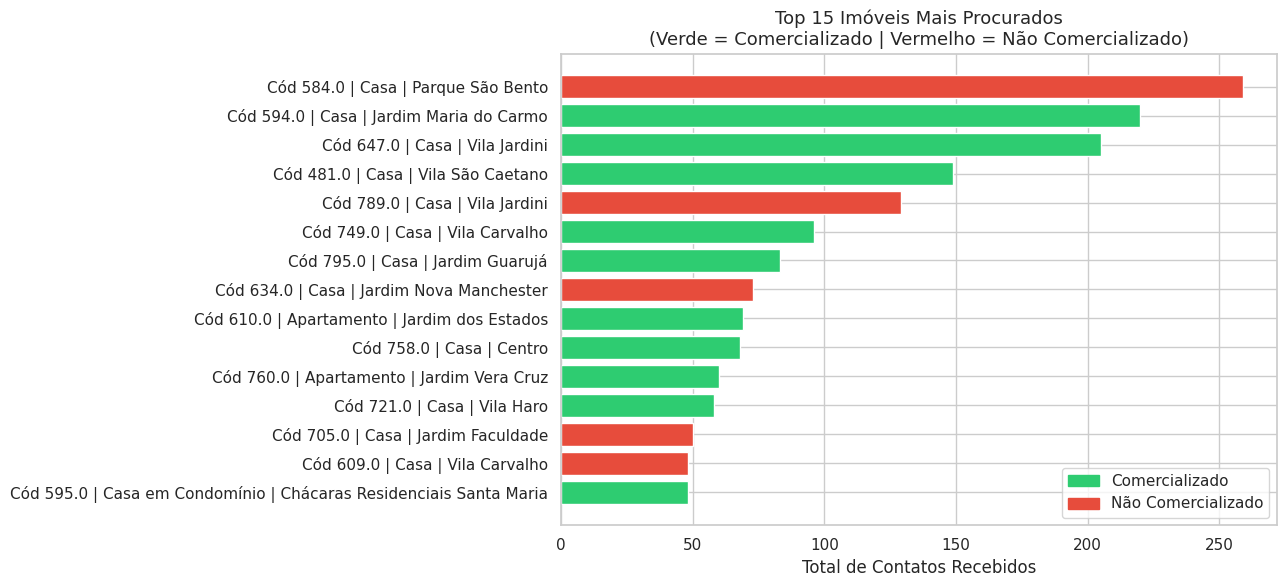

,Referência,Tipo,Bairro,Finalidade,Valor_num,total_contatos,comercializado
51,584.0,Casa,Parque São Bento,Locação,1500.0,259,0
1,594.0,Casa,Jardim Maria do Carmo,Locação,600.0,220,1
13,647.0,Casa,Vila Jardini,Locação,1100.0,205,1
60,481.0,Casa,Vila São Caetano,Locação,1700.0,149,1
4,789.0,Casa,Vila Jardini,Locação,990.0,129,0
9,749.0,Casa,Vila Carvalho,Locação,1100.0,96,1
64,795.0,Casa,Jardim Guarujá,Locação,1700.0,83,1
258,634.0,Casa,Jardim Nova Manchester,Venda,290000.0,73,0
19,610.0,Apartamento,Jardim dos Estados,Locação,1190.0,69,1
231,758.0,Casa,Centro,Venda,210000.0,68,1


In [18]:
# ──────────────────────────────────────────────
# 5.1 Imóveis mais procurados (Top 15)
# ──────────────────────────────────────────────
top15 = (
    df_master[df_master['total_contatos'] > 0]
    .nlargest(15, 'total_contatos')
    [['Referência', 'Tipo', 'Bairro', 'Finalidade', 'Valor_num', 'total_contatos', 'comercializado']]
)

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.barh(
    top15.apply(lambda r: f"Cód {r['Referência']} | {r['Tipo']} | {r['Bairro']}", axis=1),
    top15['total_contatos'],
    color=top15['comercializado'].map({1: '#2ecc71', 0: '#e74c3c'})
)
ax.set_xlabel('Total de Contatos Recebidos')
ax.set_title('Top 15 Imóveis Mais Procurados\n(Verde = Comercializado | Vermelho = Não Comercializado)', fontsize=13)
ax.invert_yaxis()
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#2ecc71', label='Comercializado'), Patch(color='#e74c3c', label='Não Comercializado')])
plt.tight_layout()
plt.show()

display(top15)

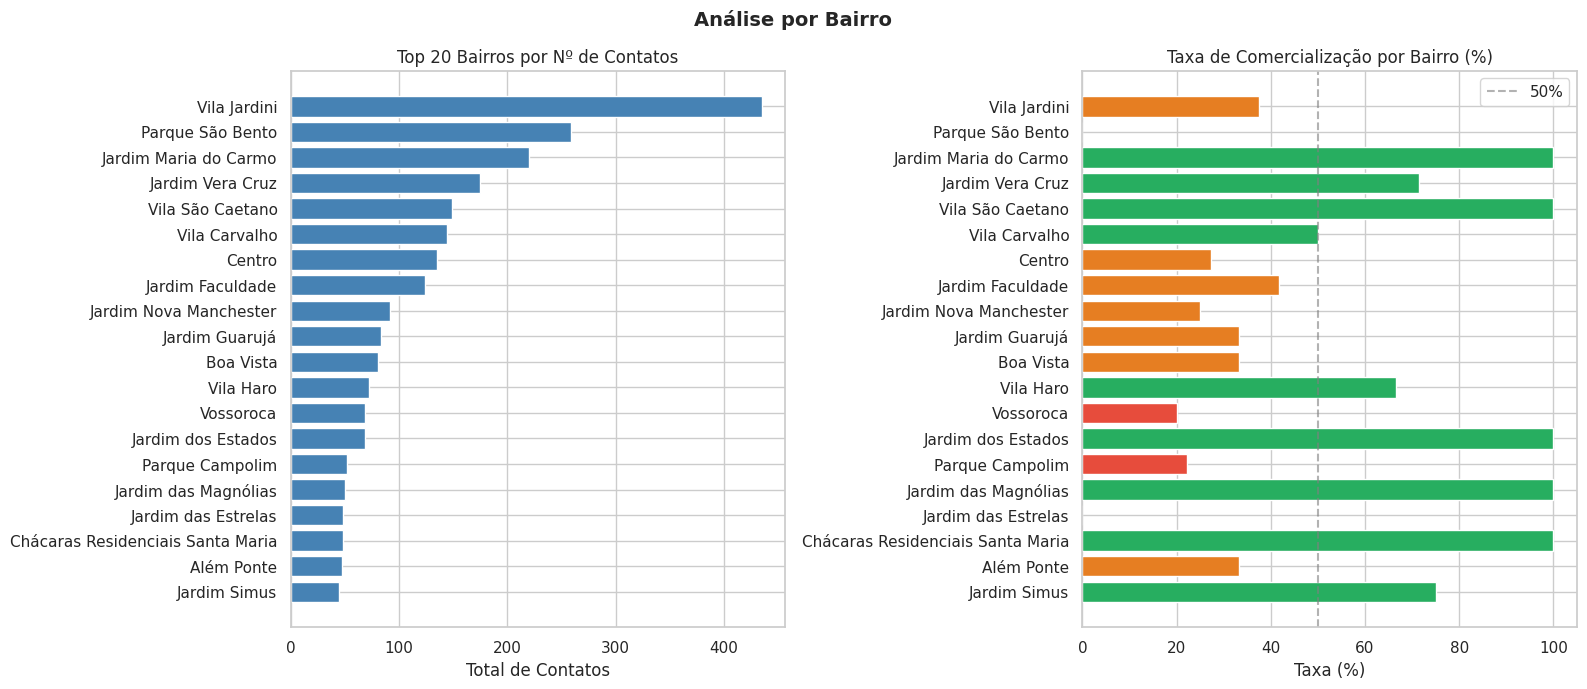


📊 Tabela completa — Top 20 Bairros:


,Bairro,total_contatos,qtd_imoveis,taxa_comercializacao
0,Vila Jardini,435,7,0.375000
1,Parque São Bento,259,2,0.000000
2,Jardim Maria do Carmo,220,1,1.000000
3,Jardim Vera Cruz,175,7,0.714286
4,Vila São Caetano,149,1,1.000000
5,Vila Carvalho,144,2,0.500000
6,Centro,135,13,0.272727
7,Jardim Faculdade,124,7,0.416667
8,Jardim Nova Manchester,92,3,0.250000
9,Jardim Guarujá,83,3,0.333333


In [19]:
# ──────────────────────────────────────────────
# 5.2 Bairros mais procurados
# ──────────────────────────────────────────────
bairros = (
    df_master
    .groupby('Bairro', dropna=True)
    .agg(
        total_contatos=('total_contatos', 'sum'),
        qtd_imoveis=('Referência', 'count'),
        taxa_comercializacao=('comercializado', 'mean')
    )
    .sort_values('total_contatos', ascending=False)
    .reset_index()
)

top_bairros = bairros.head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Volume de contatos
axes[0].barh(top_bairros['Bairro'], top_bairros['total_contatos'], color='steelblue')
axes[0].set_title('Top 20 Bairros por Nº de Contatos', fontsize=12)
axes[0].set_xlabel('Total de Contatos')
axes[0].invert_yaxis()

# Taxa de comercialização
cores = ['#27ae60' if v >= 0.5 else '#e67e22' if v >= 0.25 else '#e74c3c'
         for v in top_bairros['taxa_comercializacao']]
axes[1].barh(top_bairros['Bairro'], top_bairros['taxa_comercializacao'] * 100, color=cores)
axes[1].set_title('Taxa de Comercialização por Bairro (%)', fontsize=12)
axes[1].set_xlabel('Taxa (%)')
axes[1].invert_yaxis()
axes[1].axvline(50, color='gray', linestyle='--', alpha=0.6, label='50%')
axes[1].legend()

plt.suptitle('Análise por Bairro', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n📊 Tabela completa — Top 20 Bairros:')
display(top_bairros.head(20))

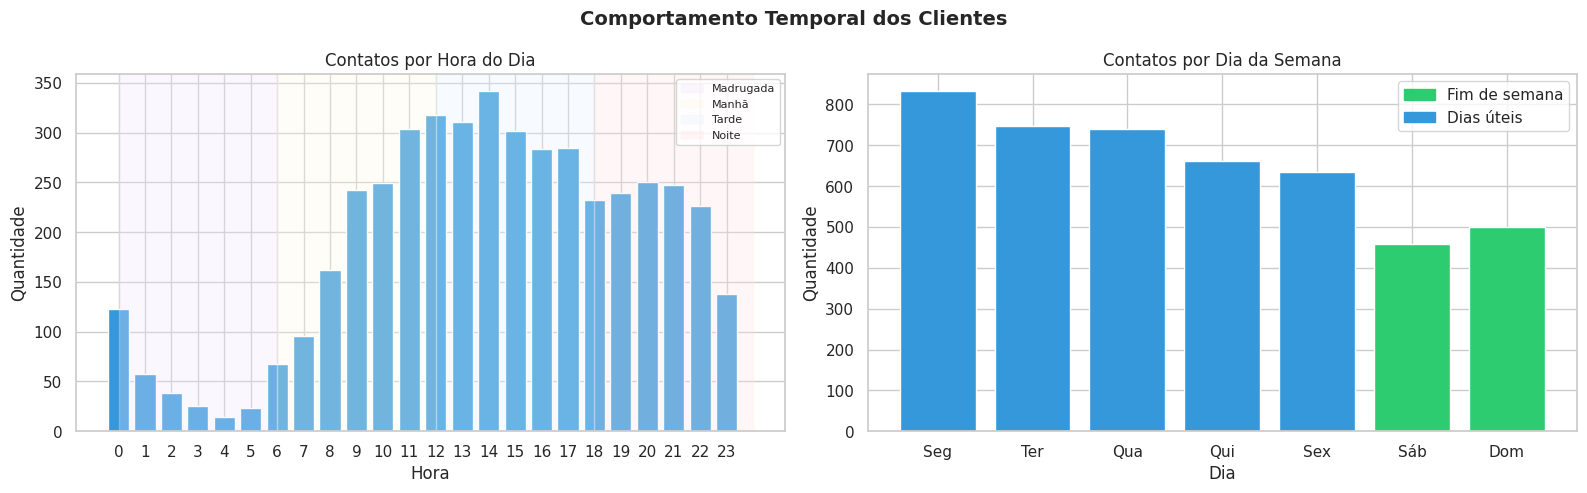

In [20]:
# ──────────────────────────────────────────────
# 5.3 Comportamento temporal dos clientes
# ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Contatos por hora do dia
hora_dist = df_contatos.dropna(subset=['hora'])['hora'].value_counts().sort_index()
axes[0].bar(hora_dist.index, hora_dist.values, color='#3498db', edgecolor='white')
axes[0].set_title('Contatos por Hora do Dia', fontsize=12)
axes[0].set_xlabel('Hora')
axes[0].set_ylabel('Quantidade')
axes[0].set_xticks(range(0, 24))
# Fundo colorido por turno
for inicio, fim, cor, label in [(0, 6, '#f0e6ff', 'Madrugada'), (6, 12, '#fff9e6', 'Manhã'),
                                 (12, 18, '#e6f4ff', 'Tarde'), (18, 24, '#ffe6e6', 'Noite')]:
    axes[0].axvspan(inicio, fim, alpha=0.3, color=cor, label=label)
axes[0].legend(fontsize=8)

# Contatos por dia da semana
dias_map = {0: 'Seg', 1: 'Ter', 2: 'Qua', 3: 'Qui', 4: 'Sex', 5: 'Sáb', 6: 'Dom'}
dia_dist = (
    df_contatos.dropna(subset=['dia_semana'])['dia_semana']
    .value_counts().sort_index()
    .rename(index=dias_map)
)
axes[1].bar(dia_dist.index, dia_dist.values,
            color=['#2ecc71' if d in ['Sáb', 'Dom'] else '#3498db' for d in dia_dist.index],
            edgecolor='white')
axes[1].set_title('Contatos por Dia da Semana', fontsize=12)
axes[1].set_xlabel('Dia')
axes[1].set_ylabel('Quantidade')
from matplotlib.patches import Patch
axes[1].legend(handles=[Patch(color='#2ecc71', label='Fim de semana'), Patch(color='#3498db', label='Dias úteis')])

plt.suptitle('Comportamento Temporal dos Clientes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

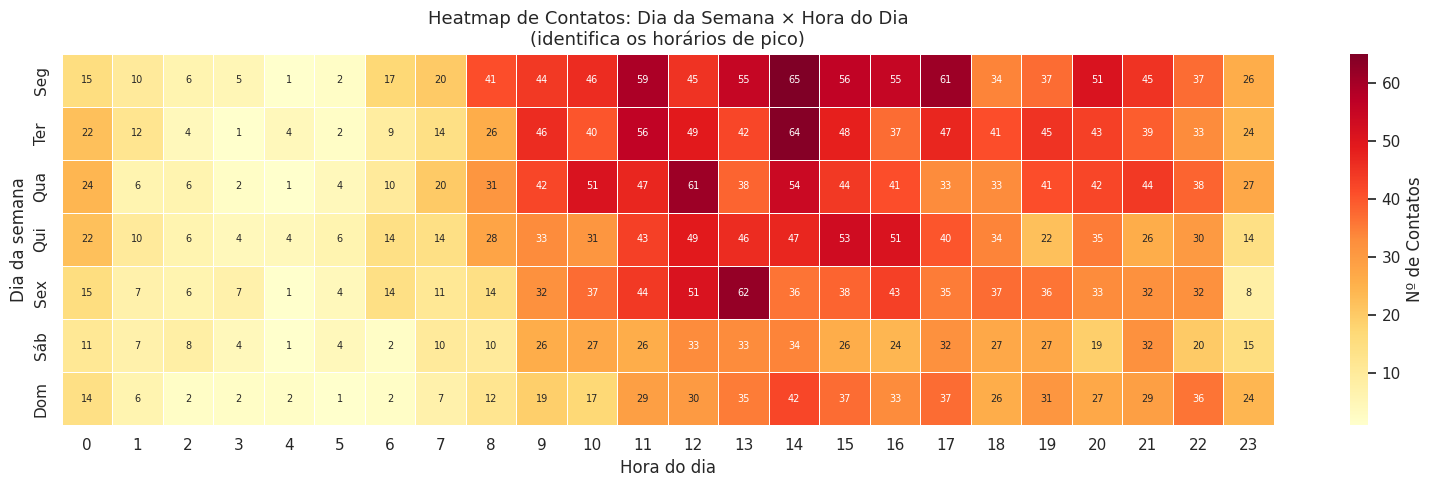

In [21]:
# ──────────────────────────────────────────────
# 5.4 Heatmap: hora × dia da semana
# ──────────────────────────────────────────────
pivot = (
    df_contatos
    .dropna(subset=['hora', 'dia_semana'])
    .groupby(['dia_semana', 'hora'])
    .size()
    .unstack(fill_value=0)
    .rename(index=dias_map)
)

plt.figure(figsize=(16, 5))
sns.heatmap(
    pivot, cmap='YlOrRd', linewidths=0.4,
    cbar_kws={'label': 'Nº de Contatos'},
    fmt='d', annot=True, annot_kws={'size': 7}
)
plt.title('Heatmap de Contatos: Dia da Semana × Hora do Dia\n(identifica os horários de pico)', fontsize=13)
plt.xlabel('Hora do dia')
plt.ylabel('Dia da semana')
plt.tight_layout()
plt.show()

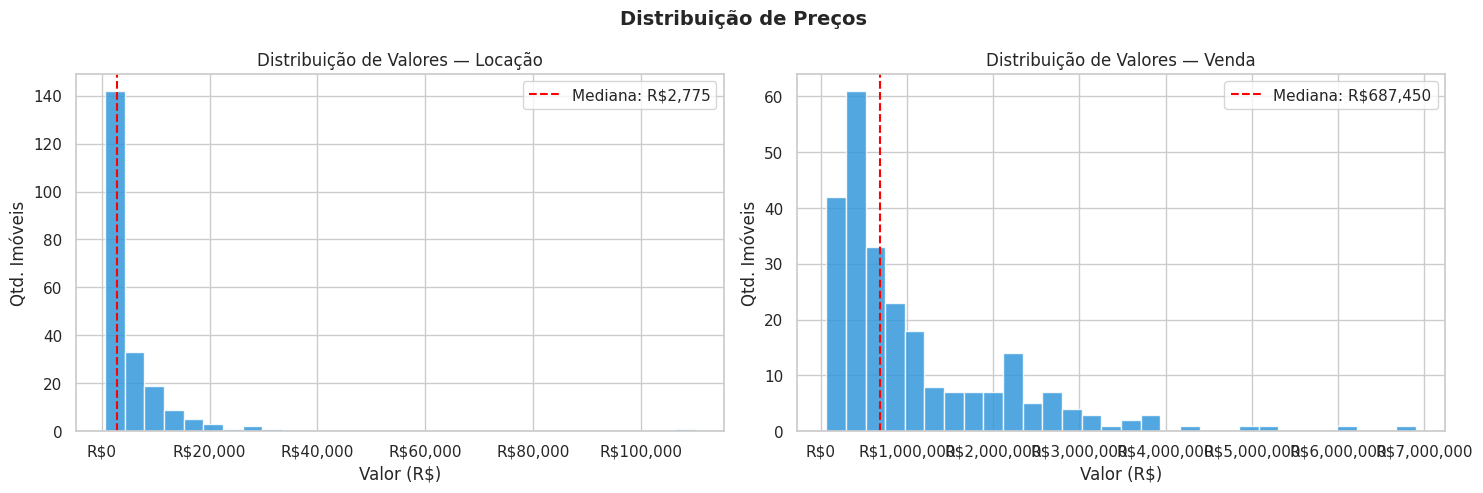

In [22]:
# ──────────────────────────────────────────────
# 5.5 Distribuição de valores por finalidade
# ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, finalidade in zip(axes, ['Locação', 'Venda']):
    subset = df_master[(df_master['Finalidade'] == finalidade) & (df_master['Valor_num'].notna())]
    ax.hist(subset['Valor_num'], bins=30, color='#3498db', edgecolor='white', alpha=0.85)
    ax.set_title(f'Distribuição de Valores — {finalidade}', fontsize=12)
    ax.set_xlabel('Valor (R$)')
    ax.set_ylabel('Qtd. Imóveis')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:,.0f}'))
    ax.axvline(subset['Valor_num'].median(), color='red', linestyle='--',
               label=f'Mediana: R${subset["Valor_num"].median():,.0f}')
    ax.legend()

plt.suptitle('Distribuição de Preços', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Mapa de Calor por Bairro/CEP

Usamos a API **ViaCEP** para geocodificar os imóveis e então plotar um mapa de calor com `folium`,  
mostrando visualmente quais regiões de Sorocaba têm maior demanda.

In [23]:
# ──────────────────────────────────────────────
# 6.1 Geocodificação via ViaCEP + Nominatim
# ──────────────────────────────────────────────
# Usamos o Nominatim (OpenStreetMap) para obter lat/lon a partir do bairro + cidade
# A API ViaCEP retorna logradouro/bairro; o Nominatim converte para coordenadas.

from urllib.parse import quote

# Cache para evitar requisições repetidas
_geocache = {}

def geocodificar_bairro(bairro, cidade='Sorocaba', estado='SP'):
    """Retorna (lat, lon) para um bairro usando Nominatim (OpenStreetMap)."""
    chave = bairro.strip().lower()
    if chave in _geocache:
        return _geocache[chave]
    query = quote(f'{bairro}, {cidade}, {estado}, Brasil')
    url = f'https://nominatim.openstreetmap.org/search?q={query}&format=json&limit=1'
    try:
        r = requests.get(url, headers={'User-Agent': 'TrabalhoAcademico/1.0'}, timeout=8)
        data = r.json()
        if data:
            lat, lon = float(data[0]['lat']), float(data[0]['lon'])
            _geocache[chave] = (lat, lon)
            time.sleep(1.1)  # respeitar limite da API Nominatim (1 req/s)
            return lat, lon
    except Exception:
        pass
    _geocache[chave] = (None, None)
    return None, None

# Geocodificar apenas bairros únicos (economiza chamadas)
bairros_unicos = df_master['Bairro'].dropna().unique()
print(f'Geocodificando {len(bairros_unicos)} bairros únicos... (pode levar alguns minutos)')

coords_bairro = {}
for i, bairro in enumerate(bairros_unicos):
    lat, lon = geocodificar_bairro(bairro)
    coords_bairro[bairro] = (lat, lon)
    if (i + 1) % 10 == 0:
        print(f'  {i+1}/{len(bairros_unicos)} processados...')

df_master['lat'] = df_master['Bairro'].map(lambda b: coords_bairro.get(b, (None, None))[0])
df_master['lon'] = df_master['Bairro'].map(lambda b: coords_bairro.get(b, (None, None))[1])

geo_ok = df_master['lat'].notna().sum()
print(f'\n✅ Geocodificação concluída: {geo_ok}/{len(df_master)} imóveis com coordenadas')

Geocodificando 165 bairros únicos... (pode levar alguns minutos)
  10/165 processados...
  20/165 processados...
  30/165 processados...
  40/165 processados...
  50/165 processados...
  60/165 processados...
  70/165 processados...
  80/165 processados...
  90/165 processados...
  100/165 processados...
  110/165 processados...
  120/165 processados...
  130/165 processados...
  140/165 processados...
  150/165 processados...
  160/165 processados...

✅ Geocodificação concluída: 323/467 imóveis com coordenadas


In [24]:
# ──────────────────────────────────────────────
# 6.2 Mapa de calor de demanda por bairro
# ──────────────────────────────────────────────

df_geo = df_master[df_master['lat'].notna() & (df_master['total_contatos'] > 0)].copy()

# Centro: Sorocaba - SP
mapa = folium.Map(location=[-23.5015, -47.4526], zoom_start=13, tiles='CartoDB positron')

# Dados para o heatmap: [lat, lon, peso]
heat_data = [
    [row['lat'], row['lon'], row['total_contatos']]
    for _, row in df_geo.iterrows()
]
HeatMap(heat_data, radius=25, blur=15, max_zoom=14).add_to(mapa)

# Marcadores por bairro (agrupados)
resumo_geo = (
    df_geo.groupby('Bairro')
    .agg(contatos=('total_contatos', 'sum'), lat=('lat', 'first'), lon=('lon', 'first'))
    .reset_index()
)

for _, row in resumo_geo.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=min(20, 3 + row['contatos'] * 0.3),
        color='#e74c3c',
        fill=True,
        fill_opacity=0.6,
        popup=folium.Popup(f"<b>{row['Bairro']}</b><br>Contatos: {row['contatos']}", max_width=200)
    ).add_to(mapa)

mapa.save('mapa_demanda_imoveis.html')
print('✅ Mapa salvo em mapa_demanda_imoveis.html')
mapa  # exibe inline no Colab

✅ Mapa salvo em mapa_demanda_imoveis.html


---
## 7. Clusterização K-Means

Agrupamos os imóveis em clusters com base em características numéricas,  
para identificar perfis distintos (ex: imóvel econômico de alta demanda vs. imóvel premium de baixa demanda).

In [25]:
# ──────────────────────────────────────────────
# 7.1 Preparar features para clusterização
# ──────────────────────────────────────────────
features_cluster = ['Valor_num', 'dormitorios', 'banheiros', 'garagens', 'suites', 'total_contatos']

df_cluster = df_master[features_cluster].copy()

# Imputar nulos com mediana
imputer = SimpleImputer(strategy='median')
X_cluster = imputer.fit_transform(df_cluster)

# Normalizar
scaler_cl = StandardScaler()
X_scaled = scaler_cl.fit_transform(X_cluster)

print(f'Matriz para clusterização: {X_scaled.shape}')

Matriz para clusterização: (467, 6)


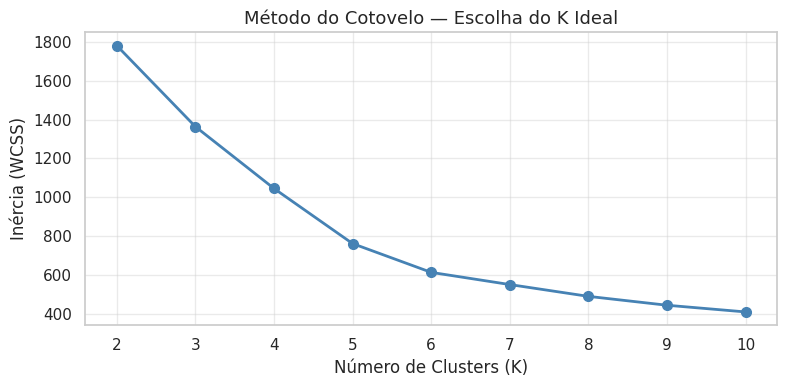

Dica: observe o ponto onde a curva "dobra" (cotovelo) — esse é o K ideal.


In [26]:
# ──────────────────────────────────────────────
# 7.2 Método do Cotovelo (Elbow) para escolher K
# ──────────────────────────────────────────────
inertias = []
ks = range(2, 11)

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(ks, inertias, 'o-', color='steelblue', linewidth=2, markersize=7)
plt.title('Método do Cotovelo — Escolha do K Ideal', fontsize=13)
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inércia (WCSS)')
plt.xticks(ks)
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()
print('Dica: observe o ponto onde a curva "dobra" (cotovelo) — esse é o K ideal.')

In [27]:
# ──────────────────────────────────────────────
# 7.3 Aplicar K-Means com K escolhido
# ──────────────────────────────────────────────
K_IDEAL = 4  # ajuste conforme o gráfico do cotovelo

kmeans = KMeans(n_clusters=K_IDEAL, random_state=42, n_init=10)
df_master['cluster'] = kmeans.fit_predict(X_scaled)

# Perfil médio por cluster
perfil_clusters = (
    df_master.groupby('cluster')[features_cluster + ['comercializado']]
    .mean()
    .round(2)
)
print('📊 Perfil médio por Cluster:')
display(perfil_clusters)

📊 Perfil médio por Cluster:


,Valor_num,dormitorios,banheiros,garagens,suites,total_contatos,comercializado
cluster,,,,,,,
0,1165.00,1.33,1.00,0.0,0.17,176.33,0.67
1,137836.09,2.03,1.22,1.0,0.27,8.33,0.29
2,343648.86,1.83,1.63,0.0,0.57,5.04,0.24
3,1555700.00,3.60,4.97,0.0,2.96,0.70,0.14


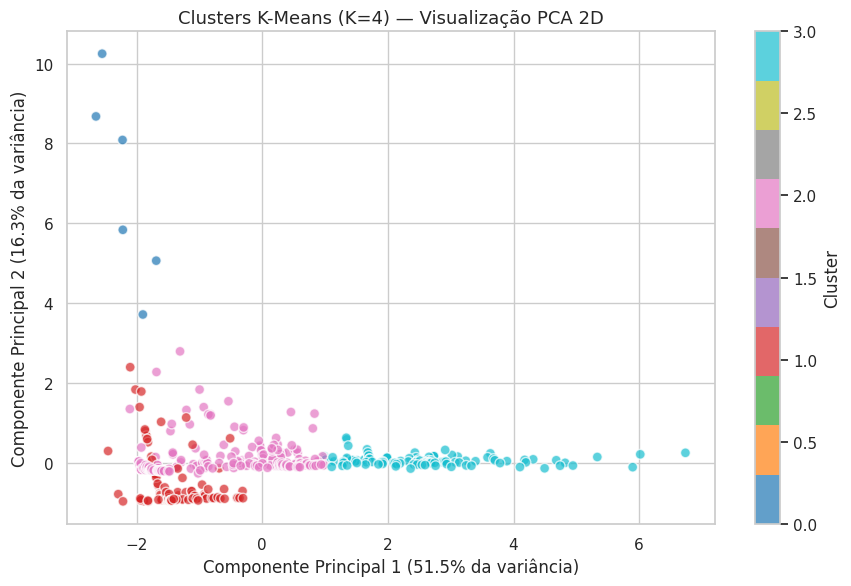

Variância total explicada pelos 2 componentes: 67.7%


In [28]:
# ──────────────────────────────────────────────
# 7.4 Visualizar clusters com PCA (2D)
# ──────────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(9, 6))
scatter = plt.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=df_master['cluster'], cmap='tab10',
    alpha=0.7, edgecolors='white', s=50
)
plt.colorbar(scatter, label='Cluster')
plt.title(f'Clusters K-Means (K={K_IDEAL}) — Visualização PCA 2D', fontsize=13)
plt.xlabel(f'Componente Principal 1 ({pca.explained_variance_ratio_[0]:.1%} da variância)')
plt.ylabel(f'Componente Principal 2 ({pca.explained_variance_ratio_[1]:.1%} da variância)')
plt.tight_layout()
plt.show()

print(f'Variância total explicada pelos 2 componentes: {pca.explained_variance_ratio_.sum():.1%}')

In [29]:
# ──────────────────────────────────────────────
# 7.5 Interpretação dos clusters
# ──────────────────────────────────────────────
# Distribuição de tipo e finalidade por cluster
print('Finalidade por cluster:')
display(pd.crosstab(df_master['cluster'], df_master['Finalidade'], normalize='index').round(2))

print('\nTipo de imóvel por cluster (top 3 por cluster):')
for c in range(K_IDEAL):
    top = df_master[df_master['cluster'] == c]['Tipo'].value_counts().head(3)
    print(f'  Cluster {c}: {dict(top)}')

Finalidade por cluster:


Finalidade,Locação,Venda
cluster,,
0,1.00,0.00
1,0.59,0.41
2,0.45,0.55
3,0.32,0.68



Tipo de imóvel por cluster (top 3 por cluster):
  Cluster 0: {'Casa': np.int64(6)}
  Cluster 1: {'Apartamento': np.int64(73), 'Casa': np.int64(28), 'Flat': np.int64(7)}
  Cluster 2: {'Casa': np.int64(59), 'Apartamento': np.int64(50), 'Casa em Condomínio': np.int64(36)}
  Cluster 3: {'Casa em Condomínio': np.int64(76), 'Apartamento': np.int64(25), 'Casa': np.int64(11)}


---
## 8. Engenharia de Features para a Regressão Logística

Preparamos as variáveis independentes (X) e a variável-alvo (y = `comercializado`).

In [30]:
# ──────────────────────────────────────────────
# 8.1 Selecionar e codificar features
# ──────────────────────────────────────────────

# Features numéricas
features_num = ['Valor_num', 'Valor IPTU_num', 'Valor Condomínio_num',
                'dormitorios', 'suites', 'banheiros', 'garagens',
                'total_contatos', 'cluster']

# Features categóricas (codificação one-hot)
features_cat = ['Finalidade', 'Tipo']

# Usar apenas imóveis onde Disponibilidade está explicitamente definida
# (NaN = imóvel ativo sem desfecho conhecido, excluído por enquanto)
df_model = df_master[df_master['Disponibilidade'].notna()].copy()

# Simplificar tipos de imóvel em categorias maiores
def simplificar_tipo(t):
    t = str(t)
    if 'Apartamento' in t or 'Flat' in t or 'Studio' in t:
        return 'Apartamento'
    elif 'Casa' in t or 'Sobrado' in t:
        return 'Casa'
    elif 'Terreno' in t or 'Lote' in t or 'Área' in t:
        return 'Terreno/Lote'
    elif 'Comercial' in t or 'Salão' in t or 'Barracão' in t or 'Galpão' in t or 'Loja' in t:
        return 'Comercial'
    else:
        return 'Outro'

df_model['tipo_simples'] = df_model['Tipo'].apply(simplificar_tipo)

# One-hot encoding
df_dummies = pd.get_dummies(
    df_model[['Finalidade', 'tipo_simples']],
    drop_first=True   # evita multicolinearidade
).astype(int)

# Montar X final
X = pd.concat([
    df_model[features_num].reset_index(drop=True),
    df_dummies.reset_index(drop=True)
], axis=1)

y = df_model['comercializado'].reset_index(drop=True)

print(f'Dataset de modelagem: {X.shape[0]} amostras × {X.shape[1]} features')
print(f'Distribuição da variável-alvo: {y.value_counts().to_dict()}')
display(X.head())

Dataset de modelagem: 237 amostras × 14 features
Distribuição da variável-alvo: {0: 128, 1: 109}


,Valor_num,Valor IPTU_num,Valor Condomínio_num,dormitorios,suites,banheiros,garagens,total_contatos,cluster,Finalidade_Venda,tipo_simples_Casa,tipo_simples_Comercial,tipo_simples_Outro,tipo_simples_Terreno/Lote
0,600.0,25.0,NaN,1,0,1,0,220,0,0,1,0,0,0
1,750.0,50.0,220.0,2,0,1,1,0,1,0,0,0,0,0
2,900.0,240.0,329.0,2,0,1,1,27,1,0,0,0,0,0
3,1000.0,NaN,NaN,0,0,1,1,4,1,0,0,1,0,0
4,1000.0,100.0,400.0,2,0,0,1,0,1,0,1,0,0,0


In [31]:
# ──────────────────────────────────────────────
# 8.2 Imputação e normalização
# ──────────────────────────────────────────────
imputer_m = SimpleImputer(strategy='median')
X_imp = pd.DataFrame(imputer_m.fit_transform(X), columns=X.columns)

scaler = StandardScaler()
X_scaled_m = scaler.fit_transform(X_imp)

# Divisão treino/teste (80/20) estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_m, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras')
print(f'Proporção alvo no treino: {y_train.mean():.2%}')
print(f'Proporção alvo no teste:  {y_test.mean():.2%}')

Treino: 189 amostras | Teste: 48 amostras
Proporção alvo no treino: 46.03%
Proporção alvo no teste:  45.83%


---
## 9. Modelagem — Regressão Logística

A **Regressão Logística** é um modelo de classificação que estima a **probabilidade** de um evento binário ocorrer.  
Aqui, estimamos P(imóvel ser comercializado | características do imóvel).

É o modelo central deste trabalho, complementado por Random Forest e Gradient Boosting para comparação.

In [32]:
# ──────────────────────────────────────────────
# 9.1 Treinar Regressão Logística
# ──────────────────────────────────────────────
log_reg = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
log_reg.fit(X_train, y_train)

# Predições
y_pred_lr  = log_reg.predict(X_test)
y_prob_lr  = log_reg.predict_proba(X_test)[:, 1]

print('=== Regressão Logística ===')
print(classification_report(y_test, y_pred_lr, target_names=['Não Comercializado', 'Comercializado']))
print(f'AUC-ROC: {roc_auc_score(y_test, y_prob_lr):.4f}')

=== Regressão Logística ===
                    precision    recall  f1-score   support

Não Comercializado       0.71      0.46      0.56        26
    Comercializado       0.55      0.77      0.64        22

          accuracy                           0.60        48
         macro avg       0.63      0.62      0.60        48
      weighted avg       0.63      0.60      0.60        48

AUC-ROC: 0.7089


In [33]:
# ──────────────────────────────────────────────
# 9.2 Comparar com Random Forest e Gradient Boosting
# ──────────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

gb = GradientBoostingClassifier(n_estimators=200, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
y_prob_gb = gb.predict_proba(X_test)[:, 1]

# Tabela comparativa
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

resultados = pd.DataFrame({
    'Modelo': ['Regressão Logística', 'Random Forest', 'Gradient Boosting'],
    'Acurácia': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_gb)
    ],
    'AUC-ROC': [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_gb)
    ]
}).set_index('Modelo').round(4)

print('📊 Comparação de Modelos:')
display(resultados.style.highlight_max(color='#d4f5d4', axis=0))

📊 Comparação de Modelos:


,Acurácia,F1-Score,AUC-ROC
Modelo,,,
Regressão Logística,0.604200,0.641500,0.708900
Random Forest,0.666700,0.652200,0.737800
Gradient Boosting,0.625000,0.608700,0.672200


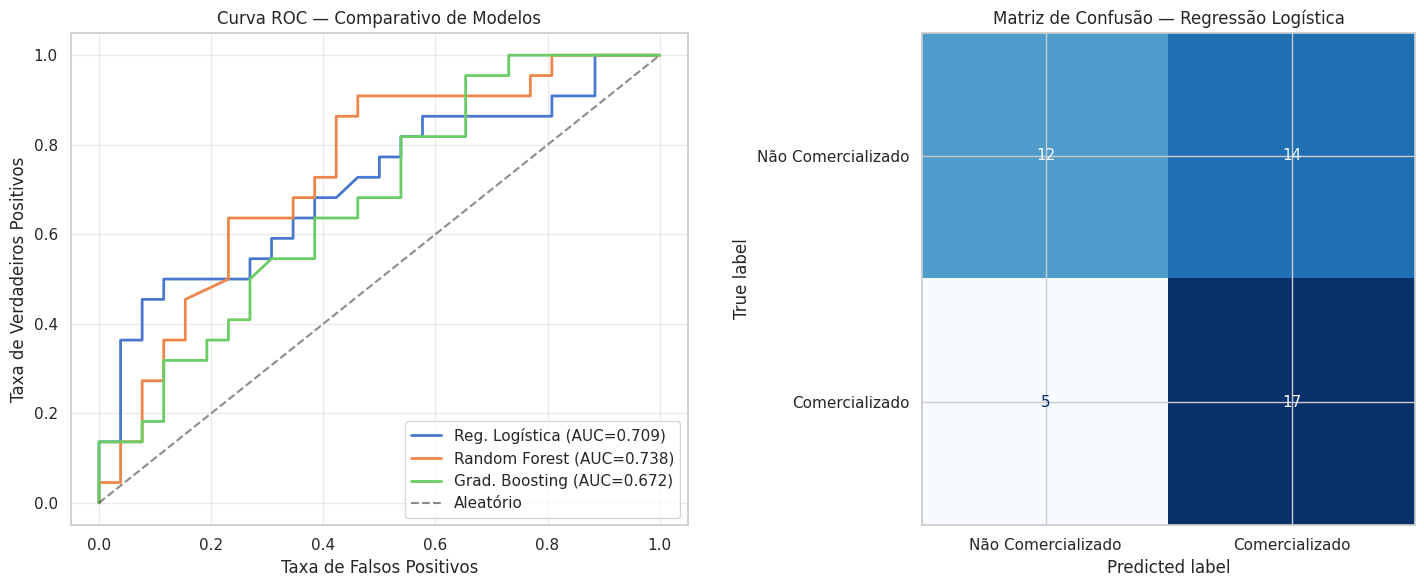

In [34]:
# ──────────────────────────────────────────────
# 9.3 Curva ROC — comparativo
# ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Curva ROC
ax = axes[0]
for nome, probs in [('Reg. Logística', y_prob_lr), ('Random Forest', y_prob_rf), ('Grad. Boosting', y_prob_gb)]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, linewidth=2, label=f'{nome} (AUC={auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Aleatório')
ax.set_title('Curva ROC — Comparativo de Modelos', fontsize=12)
ax.set_xlabel('Taxa de Falsos Positivos')
ax.set_ylabel('Taxa de Verdadeiros Positivos')
ax.legend()
ax.grid(alpha=0.4)

# Matriz de confusão — Regressão Logística
cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(cm, display_labels=['Não Comercializado', 'Comercializado'])
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Matriz de Confusão — Regressão Logística', fontsize=12)

plt.tight_layout()
plt.show()

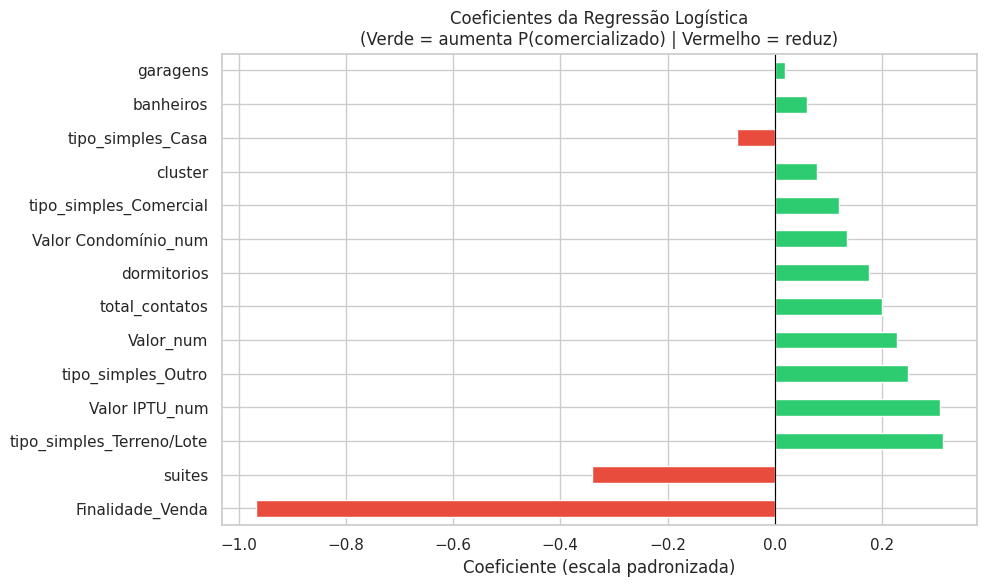

In [35]:
# ──────────────────────────────────────────────
# 9.4 Importância das variáveis — Regressão Logística
# ──────────────────────────────────────────────
coefs = pd.Series(log_reg.coef_[0], index=X_imp.columns).sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 6))
cores = ['#e74c3c' if v < 0 else '#2ecc71' for v in coefs]
coefs.plot(kind='barh', color=cores)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Coeficientes da Regressão Logística\n(Verde = aumenta P(comercializado) | Vermelho = reduz)', fontsize=12)
plt.xlabel('Coeficiente (escala padronizada)')
plt.tight_layout()
plt.show()

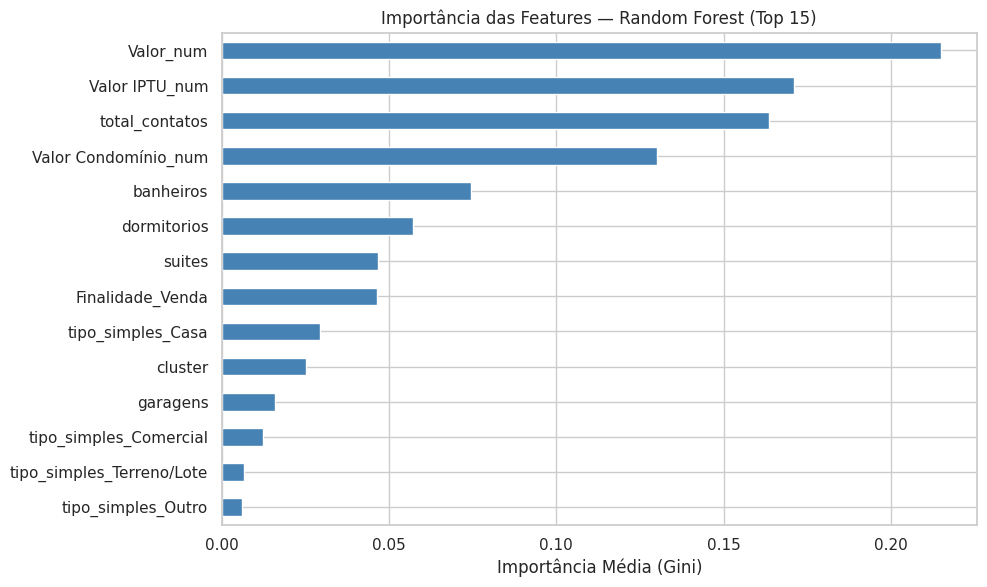

In [36]:
# ──────────────────────────────────────────────
# 9.5 Importância das variáveis — Random Forest
# ──────────────────────────────────────────────
feat_imp = pd.Series(rf.feature_importances_, index=X_imp.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
feat_imp.tail(15).plot(kind='barh', color='steelblue')
plt.title('Importância das Features — Random Forest (Top 15)', fontsize=12)
plt.xlabel('Importância Média (Gini)')
plt.tight_layout()
plt.show()

In [37]:
# ──────────────────────────────────────────────
# 9.6 Validação cruzada (cross-validation)
# ──────────────────────────────────────────────
# Garante que o resultado não depende de um único split aleatório

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for nome, modelo in [('Regressão Logística', log_reg), ('Random Forest', rf)]:
    scores = cross_val_score(modelo, X_scaled_m, y, cv=cv, scoring='roc_auc')
    print(f'{nome}: AUC médio = {scores.mean():.4f} (±{scores.std():.4f})')

Regressão Logística: AUC médio = 0.6415 (±0.0420)
Random Forest: AUC médio = 0.6507 (±0.0390)


---
## 10. Previsão para Imóveis Ativos

Aplicamos o modelo treinado para prever a probabilidade de comercialização  
dos imóveis que ainda estão **Disponíveis** (sem desfecho conhecido).

In [38]:
# ──────────────────────────────────────────────
# 10.1 Aplicar modelo nos imóveis ativos
# ──────────────────────────────────────────────
df_ativos = df_master[
    (df_master['Disponibilidade'].isna()) |
    (df_master['Disponibilidade'] == 'Disponível')
].copy()

if len(df_ativos) > 0:
    # Preparar features dos ativos (mesmas colunas do treino)
    df_ativos['tipo_simples'] = df_ativos['Tipo'].apply(simplificar_tipo)
    dummies_ativos = pd.get_dummies(df_ativos[['Finalidade', 'tipo_simples']], drop_first=True).astype(int)
    X_ativos = pd.concat([
        df_ativos[features_num].reset_index(drop=True),
        dummies_ativos.reset_index(drop=True)
    ], axis=1)
    # Alinhar colunas (pode faltar alguma categoria)
    X_ativos = X_ativos.reindex(columns=X_imp.columns, fill_value=0)
    X_ativos_imp = pd.DataFrame(imputer_m.transform(X_ativos), columns=X_ativos.columns)
    X_ativos_scaled = scaler.transform(X_ativos_imp)

    df_ativos['prob_comercializacao'] = log_reg.predict_proba(X_ativos_scaled)[:, 1]

    ranking = (
        df_ativos[['Referência', 'Tipo', 'Bairro', 'Finalidade',
                   'Valor_num', 'total_contatos', 'prob_comercializacao']]
        .sort_values('prob_comercializacao', ascending=False)
        .head(20)
    )

    print('🏆 Top 20 Imóveis Ativos com Maior Probabilidade de Comercialização:')
    display(ranking.style.background_gradient(subset=['prob_comercializacao'], cmap='Greens'))
else:
    print('Nenhum imóvel ativo encontrado para previsão.')

🏆 Top 20 Imóveis Ativos com Maior Probabilidade de Comercialização:


,Referência,Tipo,Bairro,Finalidade,Valor_num,total_contatos,prob_comercializacao
211,nan,Galpão,Iporanga,Locação,20474.000000,0,0.934971
208,nan,Galpão,Iporanga,Locação,18010.000000,0,0.915518
466,nan,Casa em Condomínio,Condomínio Fazenda Lago Azul,Venda,6900000.000000,0,0.891733
141,nan,Terreno,Parque Campolim,Locação,4000.000000,0,0.868317
128,418.000000,Terreno,Jardim Novo Horizonte,Locação,3500.000000,2,0.858008
51,584.000000,Casa,Parque São Bento,Locação,1500.000000,259,0.849676
213,nan,Casa em Condomínio,Condomínio Fazenda Lago Azul,Locação,27000.000000,0,0.764310
465,nan,Casa em Condomínio,Além Ponte,Venda,6000000.000000,0,0.720999
215,516.000000,Comercial,Parque Campolim,Locação,32000.000000,4,0.715506
463,nan,Casa em Condomínio,Jardim Village Saint Charbel,Venda,5000000.000000,0,0.688093


---
## 11. Resumo dos Insights de Negócio

Esta célula consolida as principais descobertas para apresentação.

In [39]:
# ──────────────────────────────────────────────
# 11.1 Dashboard de insights
# ──────────────────────────────────────────────

print('=' * 60)
print('           RESUMO DE INSIGHTS — MERCADO IMOBILIÁRIO')
print('=' * 60)

# 1. Volume geral
print(f'\n📨 Total de contatos recebidos : {len(df_contatos):,}')
print(f'🏠 Total de imóveis cadastrados : {len(df_imoveis):,}')
print(f'   - Para locação              : {(df_imoveis["Finalidade"]=="Locação").sum()}')
print(f'   - Para venda                : {(df_imoveis["Finalidade"]=="Venda").sum()}')

# 2. Taxa de comercialização
tx = df_imoveis[df_imoveis['Disponibilidade'].notna()]
comercializados = tx['Disponibilidade'].isin(['Alugado', 'Vendido']).sum()
print(f'\n✅ Taxa de comercialização geral: {comercializados/len(tx):.1%}')

# 3. Bairro mais procurado
bairro_top = bairros.iloc[0]
print(f'\n🏆 Bairro mais procurado: {bairro_top["Bairro"]} ({bairro_top["total_contatos"]:.0f} contatos)')

# 4. Horário de pico
hora_pico = hora_dist.idxmax()
print(f'⏰ Horário de pico de contatos : {hora_pico}h ({hora_dist[hora_pico]:,} mensagens)')

# 5. Dia de pico
dia_pico = dia_dist.idxmax()
print(f'📅 Dia de maior demanda        : {dia_pico}')

# 6. Modelo
auc = roc_auc_score(y_test, y_prob_lr)
print(f'\n🤖 Regressão Logística — AUC-ROC: {auc:.3f}')
print('   (AUC > 0.7 é considerado bom; > 0.8 é excelente)')

# 7. Features mais relevantes
top_features = coefs.abs().sort_values(ascending=False).head(3).index.tolist()
print(f'   Variáveis mais importantes   : {", ".join(top_features)}')

print('\n' + '=' * 60)

           RESUMO DE INSIGHTS — MERCADO IMOBILIÁRIO

📨 Total de contatos recebidos : 4,576
🏠 Total de imóveis cadastrados : 467
   - Para locação              : 216
   - Para venda                : 251

✅ Taxa de comercialização geral: 46.0%

🏆 Bairro mais procurado: Vila Jardini (435 contatos)
⏰ Horário de pico de contatos : 14h (342 mensagens)
📅 Dia de maior demanda        : Seg

🤖 Regressão Logística — AUC-ROC: 0.709
   (AUC > 0.7 é considerado bom; > 0.8 é excelente)
   Variáveis mais importantes   : Finalidade_Venda, suites, tipo_simples_Terreno/Lote



In [40]:
# ──────────────────────────────────────────────
# 11.2 Salvar bases limpas + tabelona em Excel
# ──────────────────────────────────────────────
# Exportamos 4 arquivos:
#   1. contatos_limpo.xlsx    — base de contatos tratada
#   2. imoveis_limpo.xlsx     — base de imóveis com features extraídas
#   3. cadastros_limpo.xlsx   — cadastros sem ruído
#   4. tabelona_master.xlsx   — tabela unificada (usada no modelo)

from openpyxl import Workbook

def salvar_xlsx(df, nome):
    df.to_excel(nome, index=False, engine='openpyxl')
    print(f'   ✅ {nome} ({df.shape[0]:,} linhas × {df.shape[1]} colunas)')

print('💾 Salvando arquivos...')
salvar_xlsx(df_contatos,  'contatos_limpo.xlsx')
salvar_xlsx(df_imoveis,   'imoveis_limpo.xlsx')
salvar_xlsx(df_cadastros, 'cadastros_limpo.xlsx')
salvar_xlsx(df_master,    'tabelona_master.xlsx')

# ── Tabelona também em CSV (UTF-8 com BOM — abre direto no Excel BR)
df_master.to_csv('tabelona_master.csv', index=False, encoding='utf-8-sig')
print('   ✅ tabelona_master.csv (UTF-8 BOM — abre corretamente no Excel Brasil)')

# ── Download automático no Colab
from google.colab import files
for arq in ['contatos_limpo.xlsx', 'imoveis_limpo.xlsx', 'cadastros_limpo.xlsx',
            'tabelona_master.xlsx', 'tabelona_master.csv', 'mapa_demanda_imoveis.html']:
    files.download(arq)

print('\n🎉 Todos os arquivos disponíveis para download!')

💾 Salvando arquivos...
   ✅ contatos_limpo.xlsx (4,576 linhas × 11 colunas)
   ✅ imoveis_limpo.xlsx (467 linhas × 23 colunas)
   ✅ cadastros_limpo.xlsx (634 linhas × 6 colunas)
   ✅ tabelona_master.xlsx (467 linhas × 28 colunas)
   ✅ tabelona_master.csv (UTF-8 BOM — abre corretamente no Excel Brasil)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 Todos os arquivos disponíveis para download!


---
## Conclusão

Este notebook realizou:

1. **ETL completo** — junção das 3 bases, extração de features textuais, tratamento de datas e valores monetários
2. **Análise exploratória** — ranking de imóveis e bairros mais procurados, heatmap temporal de comportamento do cliente
3. **Mapa geográfico interativo** — visualização de calor por bairro em Sorocaba
4. **Clusterização K-Means** — segmentação de imóveis em perfis distintos de valor e demanda
5. **Regressão Logística** — previsão da probabilidade de um imóvel ser comercializado, com comparativo contra Random Forest e Gradient Boosting
6. **Scoring de imóveis ativos** — ranking de oportunidades para a equipe comercial priorizar

**Possíveis extensões:**
- Incorporar sazonalidade (meses com maior demanda)
- Análise de texto das mensagens (NLP) para classificar intenção do lead
- Modelo de regressão para previsão do valor de mercado
- Integração com API do Google Maps para distância até pontos de interesse